In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# source: original dataset, untouched
# kaynak: orijinal veri seti, dokunulmamis
SRC_ROOT = '/content/drive/MyDrive/Kitle-Vindr&Tekno'
assert Path(SRC_ROOT).is_dir(), f'Kaynak yok: {SRC_ROOT}'
print('Kaynak:', SRC_ROOT)

Mounted at /content/drive
Kaynak: /content/drive/MyDrive/Kitle-Vindr&Tekno


In [14]:
import cv2
import numpy as np

# user's proven settings (TwoViewDensityNet notebook)
# kullanicinin kanitli ayarlari (TwoViewDensityNet notebook)
BG_THRESH = 10       # fixed background threshold / sabit arka plan esigi
MORPH_KERNEL = 9     # opening disk size / acilma disk boyutu
PAD_RATIO = 0.05     # padding around breast / meme etrafi pay


def crop_breast_xy(img_gray, padding_ratio=PAD_RATIO):
    # crop both axes using the largest connected component bounding box
    # en buyuk bagli bilesen kutusu ile iki eksende kirp
    # returns x1, x2, y1, y2, cropped_flag
    # dondurur: x1, x2, y1, y2, kirpildi_bayragi
    h_img, w_img = img_gray.shape

    _, binary = cv2.threshold(img_gray, BG_THRESH, 255, cv2.THRESH_BINARY)
    disk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, disk)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
    if num_labels <= 1:
        return 0, w_img, 0, h_img, False
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    component = (labels == largest).astype(np.uint8)
    ys, xs = np.where(component > 0)
    if len(xs) == 0:
        return 0, w_img, 0, h_img, False

    x1v, x2v = xs.min(), xs.max()
    y1v, y2v = ys.min(), ys.max()
    w = x2v - x1v
    # safety: only skip crop if detection is absurdly small
    # guvenlik: sadece tespit sacma derecede kucukse atla
    if w < 0.15 * w_img:
        return 0, w_img, 0, h_img, False

    px = int(w * padding_ratio)
    py = int((y2v - y1v) * padding_ratio)
    x1 = max(0, x1v - px)
    x2 = min(w_img, x2v + px)
    y1 = max(0, y1v - py)
    y2 = min(h_img, y2v + py)
    return x1, x2, y1, y2, True


def transform_bbox_xy(box_norm, x1, x2, y1, y2, ow, oh):
    # both x and y coordinates transform after cropping
    # kirpma sonrasi hem x hem y koordinati donusur
    cx = box_norm[0] * ow
    cy = box_norm[1] * oh
    bw = box_norm[2] * ow
    bh = box_norm[3] * oh
    nw = x2 - x1
    nh = y2 - y1
    return (cx - x1)/nw, (cy - y1)/nh, bw/nw, bh/nh


print('Kirpma fonksiyonlari hazir')

Kirpma fonksiyonlari hazir


Islenecek goruntu: 6


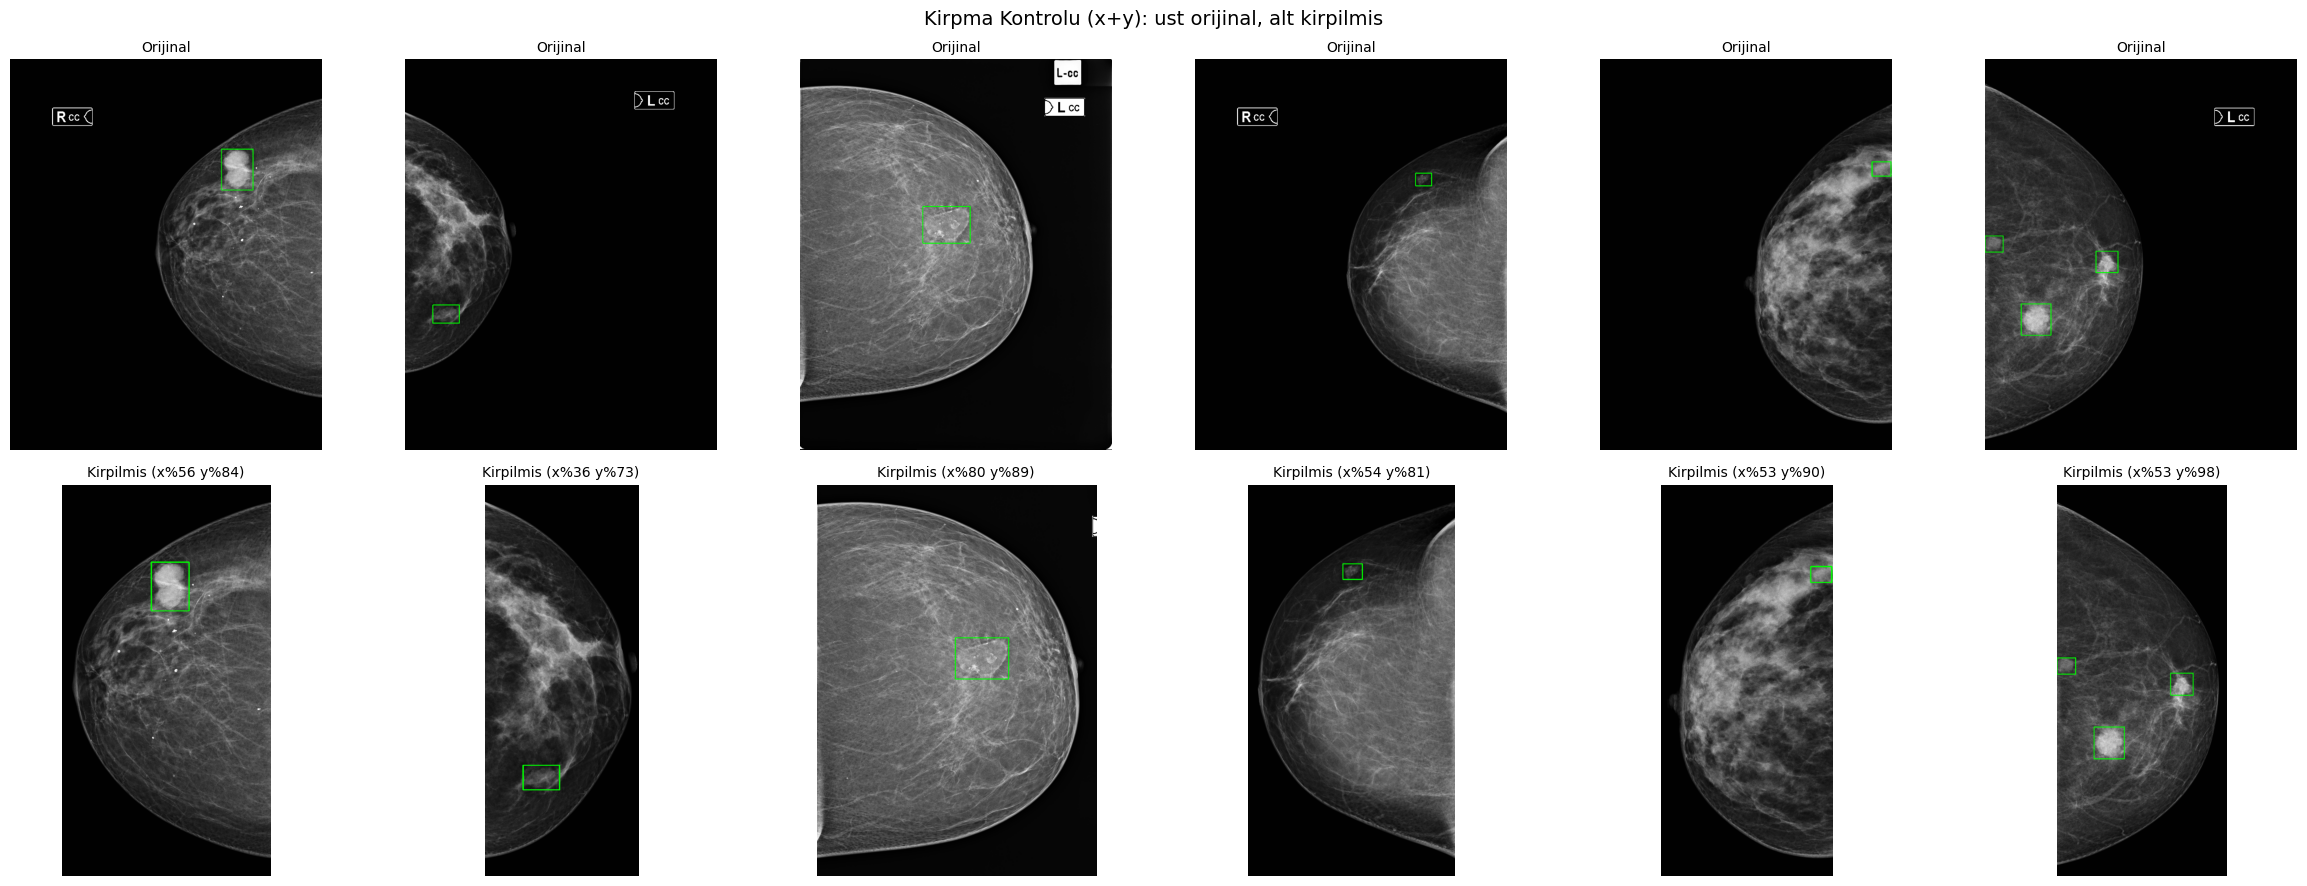

Bitti.


In [16]:
import matplotlib.pyplot as plt
import itertools

TRAIN_IMG = Path(SRC_ROOT) / 'train' / 'images'
TRAIN_LBL = Path(SRC_ROOT) / 'train' / 'labels'
DISP = 800


def load_gt(stem):
    lp = TRAIN_LBL / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


def draw_boxes(img, boxes, color, thick):
    h, w = img.shape[:2]
    for (cx, cy, bw, bh) in boxes:
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thick)
    return img


def shrink(img, maxd=DISP):
    h, w = img.shape[:2]
    s = maxd / max(h, w)
    return cv2.resize(img, (int(w*s), int(h*s)))


sample = []
for ip in itertools.islice(TRAIN_IMG.glob('*.png'), 12):
    if load_gt(ip.stem):
        sample.append(ip)
    if len(sample) == 6:
        break

print(f'Islenecek goruntu: {len(sample)}')

fig, axes = plt.subplots(2, len(sample), figsize=(4*len(sample), 9))
for col, ip in enumerate(sample):
    img = cv2.imread(str(ip))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    oh, ow = gray.shape
    gts = load_gt(ip.stem)

    # x+y crop
    # x+y kirpma
    x1, x2, y1, y2, _ = crop_breast_xy(gray)

    orig_vis = shrink(draw_boxes(img.copy(), gts, (0, 255, 0), 6))
    axes[0, col].imshow(cv2.cvtColor(orig_vis, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title('Orijinal', fontsize=10)
    axes[0, col].axis('off')

    crop = img[y1:y2, x1:x2].copy()
    new_boxes = [transform_bbox_xy(b, x1, x2, y1, y2, ow, oh) for b in gts]
    crop_vis = shrink(draw_boxes(crop, new_boxes, (0, 255, 0), 6))
    px = 100 * (x2 - x1) / ow
    py = 100 * (y2 - y1) / oh
    axes[1, col].imshow(cv2.cvtColor(crop_vis, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'Kirpilmis (x%{px:.0f} y%{py:.0f})', fontsize=10)
    axes[1, col].axis('off')

plt.suptitle('Kirpma Kontrolu (x+y): ust orijinal, alt kirpilmis', fontsize=14)
plt.tight_layout()
plt.savefig('/content/crop_check.png', dpi=80, bbox_inches='tight')
plt.show()
print('Bitti.')

In [ ]:
import os
import shutil
from tqdm import tqdm
from pathlib import Path

# local fast disk for processing, then bulk copy to Drive
# isleme icin hizli yerel disk, sonra Drive'a toplu kopya
LOCAL_PROC = '/content/cropped_local'
DST_ROOT = '/content/drive/MyDrive/Kitle-Vindr-Cropped'

splits = ['train', 'val', 'test']

# counters for the end-of-run report
# kosu sonu raporu icin sayaclar
stats_report = {sp: {'images': 0, 'cropped': 0, 'skipped': 0, 'labels': 0} for sp in splits}


def process_split(split):
    src_img_dir = Path(SRC_ROOT) / split / 'images'
    src_lbl_dir = Path(SRC_ROOT) / split / 'labels'
    dst_img_dir = Path(LOCAL_PROC) / split / 'images'
    dst_lbl_dir = Path(LOCAL_PROC) / split / 'labels'
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    imgs = sorted(src_img_dir.glob('*.png'))
    for ip in tqdm(imgs, desc=split):
        img = cv2.imread(str(ip))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        oh, ow = gray.shape

        # crop
        # kirp
        x1, x2, y1, y2, cropped = crop_breast_xy(gray)
        crop_img = img[y1:y2, x1:x2]
        cv2.imwrite(str(dst_img_dir / ip.name), crop_img)

        stats_report[split]['images'] += 1
        if cropped:
            stats_report[split]['cropped'] += 1
        else:
            stats_report[split]['skipped'] += 1

        # rewrite label if it exists
        # varsa label yeniden yaz
        lp = src_lbl_dir / f'{ip.stem}.txt'
        if lp.exists():
            new_lines = []
            for line in open(lp):
                parts = line.split()
                if len(parts) >= 5:
                    cls = parts[0]
                    cx, cy, bw, bh = [float(v) for v in parts[1:5]]
                    cx *= ow; cy *= oh; bw *= ow; bh *= oh
                    nw, nh = x2 - x1, y2 - y1
                    new_lines.append(
                        f"{cls} {(cx-x1)/nw:.6f} {(cy-y1)/nh:.6f} {bw/nw:.6f} {bh/nh:.6f}"
                    )
            with open(dst_lbl_dir / f'{ip.stem}.txt', 'w') as f:
                f.write('\n'.join(new_lines) + ('\n' if new_lines else ''))
            stats_report[split]['labels'] += len(new_lines)


# step 1: process all splits to local disk
# adim 1: tum splitleri yerel diske isle
print('Adim 1/2: Yerele isleniyor...')
if os.path.exists(LOCAL_PROC):
    shutil.rmtree(LOCAL_PROC)
for sp in splits:
    process_split(sp)

# step 2: bulk copy to Drive
# adim 2: Drive'a toplu kopyala
print('\nAdim 2/2: Drive\'a kopyalaniyor...')
if os.path.exists(DST_ROOT):
    shutil.rmtree(DST_ROOT)
shutil.copytree(LOCAL_PROC, DST_ROOT)
print('Kopyalama tamamlandi.')

# report
# rapor
print('\n=== ISLEME RAPORU ===')
for sp in splits:
    r = stats_report[sp]
    print(f'{sp:6s}: {r["images"]} goruntu, {r["cropped"]} kirpildi, '
          f'{r["skipped"]} atlandi (guvenlik), {r["labels"]} kutu')
print(f'\nKirpilmis veri: {DST_ROOT}')

Adim 1/2: Yerele isleniyor...


train:  20%|██        | 535/2671 [17:27<1:03:36,  1.79s/it]